In [2]:
import numpy as np, xarray as xr, pandas as pd
import matplotlib.pyplot as plt


In [2]:
greenland = np.load('../data/GRE_mask.npy')

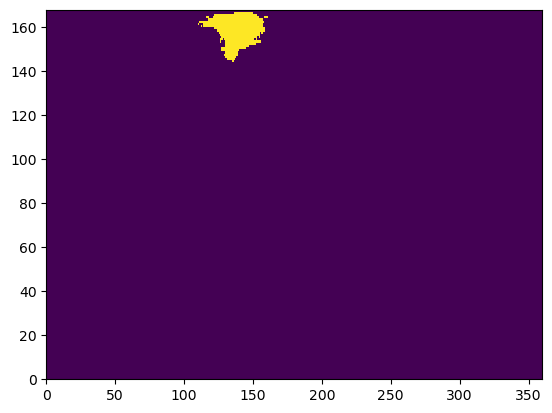

In [3]:

ds = xr.load_dataset('../data/sat1_0125.zarr')
ds

<xarray.Dataset> Size: 82MB
Dimensions:                  (lat: 180, lon: 360, spectral: 63)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 88.0 89.0
  * lon                      (lon) float64 3kB -180.0 -179.0 ... 178.0 179.0
  * spectral                 (spectral) int64 504B 0 1 2 3 4 ... 58 59 60 61 62
Data variables:
    spectral_radiance        (lat, lon, spectral) float32 16MB nan nan ... nan
    spectral_radiance_count  (lat, lon, spectral) int32 16MB 0 0 0 0 ... 0 0 0 0
    spectral_radiance_max    (lat, lon, spectral) float32 16MB 0.0 0.0 ... 0.0
    spectral_radiance_min    (lat, lon, spectral) float32 16MB inf inf ... inf
    spectral_radiance_std    (lat, lon, spectral) float32 16MB nan nan ... nan
    wavelength               (spectral) float32 252B nan nan nan ... 51.9 52.66
Attributes:
    description:  Gridded mean, std, count, min, max of spectral radiance bin...
    satellite:    sat1
    year_month:   2025-01

(168, 360) bool 573


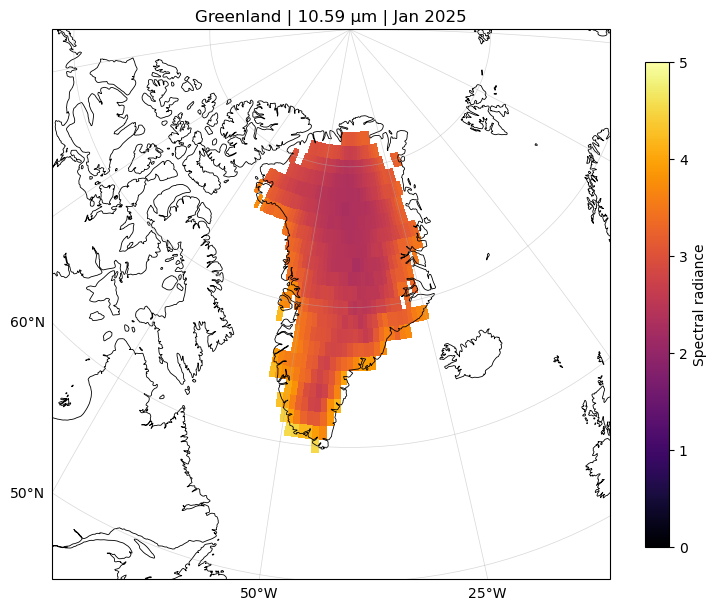

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- 1. Load the mask and check it matches the grid -------------------------
greenland = np.load('../data/GRE_mask.npy')
print(greenland.shape, greenland.dtype, greenland.sum())   # expect (180, 360)
n_lat, n_lon = greenland.shape
n_pad_total = 180 - n_lat
assert n_pad_total % 2 == 0, "asymmetric padding needed — check exact lat bounds"
n_pad = n_pad_total // 2   # rows to add on EACH side (6 if 168 -> 180)
greenland = np.pad(greenland, ((n_pad, n_pad), (0, 0)),
                        mode='constant', constant_values=0)
# If lon runs 0-360 instead of -180-180:   greenland = np.roll(greenland, 180, axis=1)
# If lat runs north->south:                greenland = greenland[::-1, :]

mask = xr.DataArray(
    greenland.astype(bool),
    dims=('lat', 'lon'),
    coords={'lat': ds.lat, 'lon': ds.lon},
    name='greenland_mask',
)
# mask.plot()          # sanity check: should light up ~60-84°N, 75-10°W
# plt.show()

# --- 2. Apply the mask ------------------------------------------------------
spec_num = 12
rad = ds.spectral_radiance.isel(spectral=spec_num)
rad_gre = rad.where(mask)            # everything outside Greenland -> NaN

# --- 3. Plot ----------------------------------------------------------------
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.Orthographic(central_latitude=72, central_longitude=-40))
ax.set_extent([-75, -10, 50, 90], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(ds.lon, ds.lat, rad_gre,
                     transform=ccrs.PlateCarree(),
                     cmap='inferno', vmin=0, vmax=5, shading='auto')
ax.coastlines(linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.right_labels = False
gl.top_labels = False
cbar = plt.colorbar(mesh, shrink=0.7, pad=0.05)
cbar.set_label('Spectral radiance')
ax.set_title(f'Greenland | {ds.wavelength.values[spec_num]:.2f} µm | Jan 2025')
plt.savefig('../gallery/trial_gre.png', dpi=300, bbox_inches='tight')
plt.show()

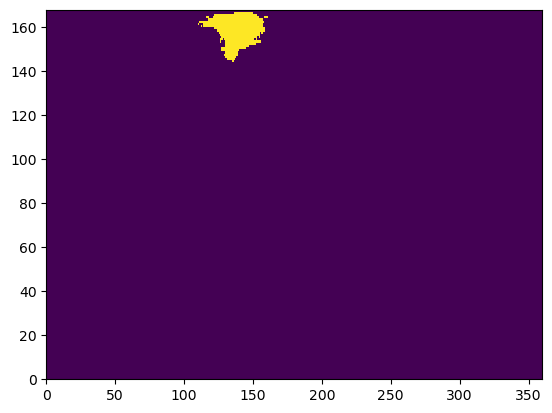

In [8]:
plt.pcolormesh(greenland)

In [9]:
n_lat, n_lon = greenland.shape

# 90N-90S at 1-deg resolution has 180 rows; 84N-84S has 168 rows (84 to -84 step -1 -> 169 actually)
# so check the exact row count you have before assuming 6 rows per side
n_pad_total = 180 - n_lat
assert n_pad_total % 2 == 0, "asymmetric padding needed — check exact lat bounds"
n_pad = n_pad_total // 2   # rows to add on EACH side (6 if 168 -> 180)

# If row 0 is 84N (i.e. lat descends from north to south, matching ds.lat[::-1]):
greenland_full = np.pad(greenland, ((n_pad, n_pad), (0, 0)),
                        mode='constant', constant_values=0)
print(greenland_full.shape)

(180, 360)
